from google.colab import files

uploaded = files.upload()


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving retail_sales_dataset (1).csv to retail_sales_dataset (1).csv


In [ ]:
df = pd.read_csv("retail_sales_dataset (1).csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [ ]:
df.head()


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [ ]:
df.shape


(1000, 9)

In [ ]:
df.columns

Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [ ]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


### Duplicate Check

The dataset contains 1,000 rows. The duplicate check returned 0 duplicate rows, so no records were removed at this stage.

### Text Consistency Check

The `Gender` column contains two consistent values: Male and Female.

The `Product Category` column contains three consistent values: Beauty, Clothing, and Electronics.

No spelling differences, inconsistent capitalisation, or extra spaces were found in these columns. Therefore, no changes were required.

In [ ]:
print("Gender values:")
print(df["Gender"].unique())

print("\nProduct categories:")
print(df["Product Category"].unique())

Gender values:
['Male' 'Female']

Product categories:
['Beauty' 'Clothing' 'Electronics']


In [ ]:
df["Date"] = pd.to_datetime(df["Date"])

print(df["Date"].dtype)
print(df["Date"].head())

datetime64[ns]
0   2023-11-24
1   2023-02-27
2   2023-01-13
3   2023-05-21
4   2023-05-06
Name: Date, dtype: datetime64[ns]


### Date Conversion

The `Date` column was initially stored as text. It was converted into the `datetime64[ns]` format using `pd.to_datetime()`. This makes the column suitable for date-based analysis such as monthly and yearly sales trends.

In [ ]:
print("Age range:")
print(df["Age"].min(), "to", df["Age"].max())

print("\nQuantity range:")
print(df["Quantity"].min(), "to", df["Quantity"].max())

print("\nPrice per Unit range:")
print(df["Price per Unit"].min(), "to", df["Price per Unit"].max())

print("\nTotal Amount range:")
print(df["Total Amount"].min(), "to", df["Total Amount"].max())

Age range:
18 to 64

Quantity range:
1 to 4

Price per Unit range:
25 to 500

Total Amount range:
25 to 2000


### Numerical Range Check

The numerical columns were checked for unusual or impossible values.

- Age ranges from 18 to 64.
- Quantity ranges from 1 to 4.
- Price per Unit ranges from 25 to 500.
- Total Amount ranges from 25 to 2,000.

The values are within reasonable ranges for this retail dataset. No negative or zero values were found, so no records were removed from the numerical columns.

In [ ]:
missing_values = df.isnull().sum()

print(missing_values)


Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64


In [23]:


print(df["Total Correct"].value_counts())

Total Correct
True    1000
Name: count, dtype: int64


### Total Amount Validation

The `Total Amount` column was checked by multiplying `Quantity` by `Price per Unit`.

All 1,000 records returned `True`, meaning every total amount is correct. No corrections were required.

In [24]:
df = df.drop(columns=["Expected Total", "Total Correct"])

print(df.columns)

Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='object')


In [25]:
cleaning_summary = pd.DataFrame({
    "Check": [
        "Rows before cleaning",
        "Columns before cleaning",
        "Duplicate rows",
        "Missing values",
        "Invalid total amounts",
        "Date conversion"
    ],
    "Result": [
        1000,
        9,
        0,
        0,
        0,
        "Completed successfully"
    ]
})

cleaning_summary


,Check,Result
0,Rows before cleaning,1000
1,Columns before cleaning,9
2,Duplicate rows,0
3,Missing values,0
4,Invalid total amounts,0
5,Date conversion,Completed successfully


In [28]:
df.to_csv("retail_sales_dataset (1).csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [29]:
category_sales = df.groupby("Product Category")["Total Amount"].sum().sort_values(ascending=False)

category_sales

,Total Amount
Product Category,
Electronics,156905
Clothing,155580
Beauty,143515


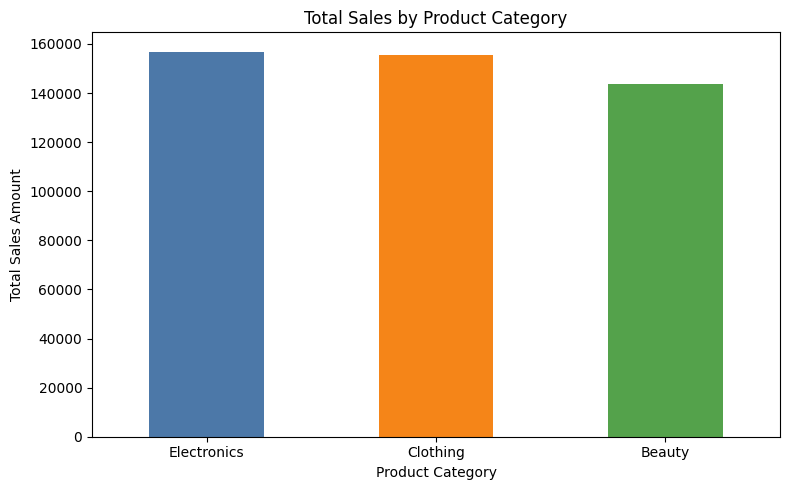

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

category_sales.plot(kind="bar", color=["#4C78A8", "#F58518", "#54A24B"])

plt.title("Total Sales by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Sales Amount")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Observation: Sales by Product Category

The bar chart compares total sales across Beauty, Clothing, and Electronics. The category with the tallest bar generated the highest total sales, while the category with the shortest bar generated the lowest total sales.

In [32]:
df.to_csv("cleaned_retail_sales.csv", index=False)

print("Cleaned file saved as cleaned_retail_sales.csv")

Cleaned file saved as cleaned_retail_sales.csv


In [33]:
monthly_sales = (
    df.groupby(df["Date"].dt.to_period("M"))["Total Amount"]
      .sum()
)

monthly_sales

,Total Amount
Date,
2023-01,35450
2023-02,44060
2023-03,28990
2023-04,33870
2023-05,53150
2023-06,36715
2023-07,35465
2023-08,36960
2023-09,23620


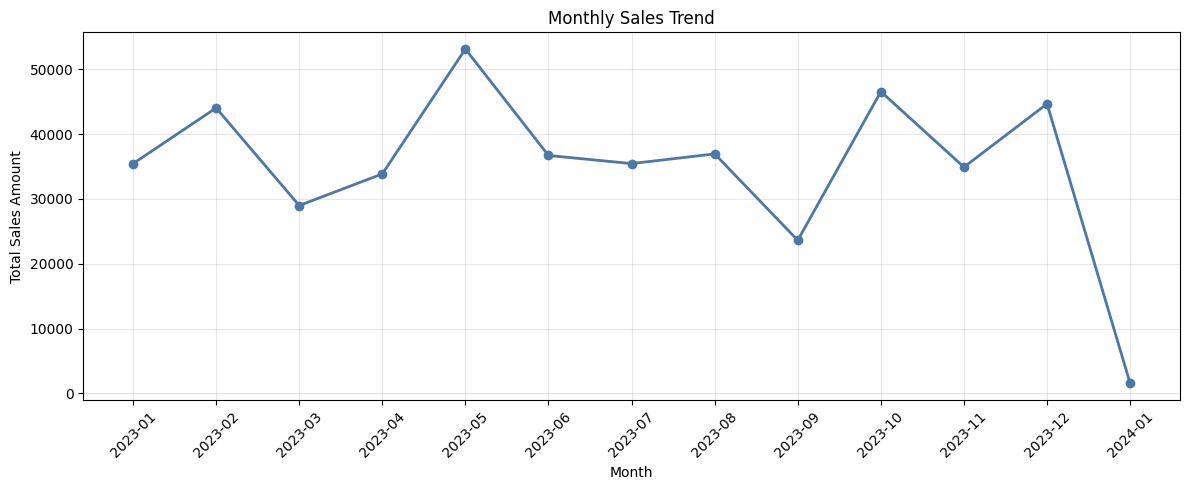

In [35]:
import matplotlib.pyplot as plt

# Group total sales by month
monthly_sales = (
    df.groupby(df["Date"].dt.to_period("M"))["Total Amount"]
      .sum()
)

# Convert the month labels to text for the chart
months = monthly_sales.index.astype(str)

# Create the line chart
plt.figure(figsize=(12, 5))
plt.plot(
    months,
    monthly_sales.values,
    marker="o",
    linewidth=2,
    color="#4C78A8"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales Amount")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Observation: Monthly Sales Trend

Sales fluctuated throughout the period. May 2023 recorded the highest complete-month sales at 53,150, while September 2023 recorded the lowest complete-month sales at 23,620. January 2024 recorded only 1,530, which may represent a partial month because the dataset contains very few records for that month.

In [36]:
gender_counts = df["Gender"].value_counts()

print(gender_counts)

Gender
Female    510
Male      490
Name: count, dtype: int64


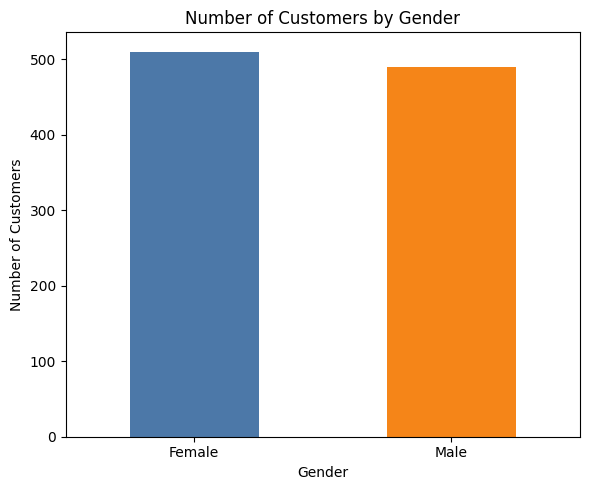

In [37]:
plt.figure(figsize=(6, 5))

gender_counts.plot(
    kind="bar",
    color=["#4C78A8", "#F58518"]
)

plt.title("Number of Customers by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Observation: Gender Distribution

The chart compares the number of transactions made by male and female customers. The gender with the taller bar represents the larger group in the dataset, while the shorter bar represents the smaller group.

In [38]:
age_bins = [17, 24, 34, 44, 54, 64]
age_labels = ["18-24", "25-34", "35-44", "45-54", "55-64"]

df["Age Group"] = pd.cut(
    df["Age"],
    bins=age_bins,
    labels=age_labels
)

age_group_counts = df["Age Group"].value_counts().sort_index()

print(age_group_counts)

Age Group
18-24    149
25-34    203
35-44    207
45-54    225
55-64    216
Name: count, dtype: int64


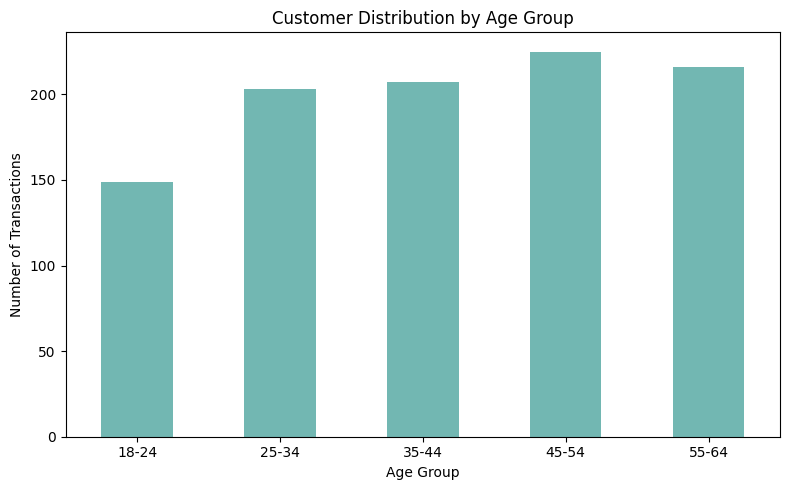

In [39]:
plt.figure(figsize=(8, 5))

age_group_counts.plot(
    kind="bar",
    color="#72B7B2"
)

plt.title("Customer Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Observation: Customer Age Groups

The chart shows the distribution of transactions across different customer age groups. The age group with the tallest bar represents the largest customer group, while the shortest bar represents the smallest customer group.

In [40]:
average_sales = (
    df.groupby("Product Category")["Total Amount"]
      .mean()
      .sort_values(ascending=False)
)

print(average_sales)

Product Category
Beauty         467.475570
Electronics    458.786550
Clothing       443.247863
Name: Total Amount, dtype: float64


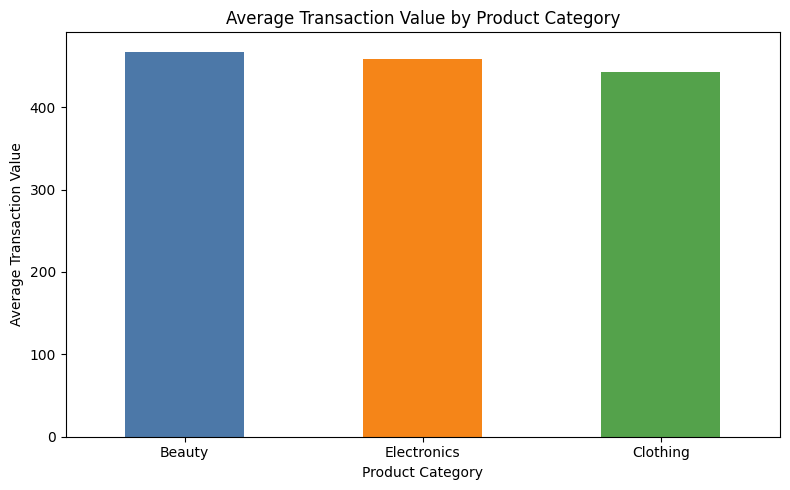

In [41]:
plt.figure(figsize=(8, 5))

average_sales.plot(
    kind="bar",
    color=["#4C78A8", "#F58518", "#54A24B"]
)

plt.title("Average Transaction Value by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Average Transaction Value")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Observation: Average Transaction Value

The chart compares the average amount spent per transaction across product categories. The category with the tallest bar has the highest average transaction value, meaning customers spend more per purchase in that category on average.

In [42]:
gender_sales = (
    df.groupby("Gender")["Total Amount"]
      .sum()
      .sort_values(ascending=False)
)

print(gender_sales)

Gender
Female    232840
Male      223160
Name: Total Amount, dtype: int64


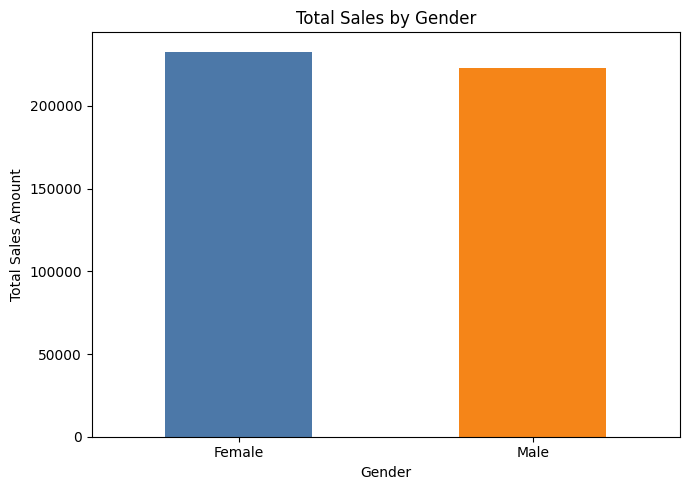

In [43]:
plt.figure(figsize=(7, 5))

gender_sales.plot(
    kind="bar",
    color=["#4C78A8", "#F58518"]
)

plt.title("Total Sales by Gender")
plt.xlabel("Gender")
plt.ylabel("Total Sales Amount")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Observation: Sales by Gender

The chart compares total sales generated by male and female customers. The gender with the taller bar contributed more revenue during the period, while the other gender contributed less.

## Final Project Summary

### Dataset Overview

The dataset contains 1,000 retail transactions and 9 original columns. The data includes transaction details, customer demographics, product categories, quantities, unit prices, and total sales amounts.

### Data Cleaning

The dataset contained no duplicate rows and no missing values. Gender and product-category values were consistent, the Date column was converted to datetime format, and all 1,000 total amounts were verified using Quantity × Price per Unit.

### Key Findings

- Electronics generated the highest total sales at 156,905.
- Beauty had the highest average transaction value at approximately 467.48.
- Female customers generated higher total sales than male customers: 232,840 compared with 223,160.
- The 45–54 age group had the highest number of transactions, with 225 purchases.
- May 2023 recorded the highest complete-month sales at 53,150.
- September 2023 recorded the lowest complete-month sales among the full months at 23,620.

### Business Recommendations

- Maintain strong stock availability for Electronics because it generated the highest total sales.
- Promote Beauty products because they produced the highest average transaction value.
- Develop targeted campaigns for customers aged 45–54, the largest age group.
- Investigate the monthly sales fluctuations to understand seasonal buying patterns.
- Use gender-based sales insights to improve customer targeting and promotional planning.

### Files Created

- `cleaned_retail_sales.csv`
- Sales-by-category chart
- Monthly-sales-trend chart
- Gender-distribution chart
- Age-group chart
- Average-transaction-value chart
- Sales-by-gender chart

In [44]:
from google.colab import files

files.download("cleaned_retail_sales.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [45]:
# Convert Date to datetime again
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

# Save dates in a clear YYYY-MM-DD format
df.to_csv(
    "cleaned_retail_sales_final.csv",
    index=False,
    date_format="%Y-%m-%d"
)

print("Final cleaned file saved successfully!")
print(df["Date"].dtype)
print(df["Date"].head())

Final cleaned file saved successfully!
datetime64[ns]
0   2023-11-24
1   2023-02-27
2   2023-01-13
3   2023-05-21
4   2023-05-06
Name: Date, dtype: datetime64[ns]


In [46]:
from google.colab import files

files.download("cleaned_retail_sales_final.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>